# Image Classification

## Step 1: Data Preprocessing and Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

* 1. --> here . is used because it consider it as a floating point.
* 255 - 1 (white - Dark)..Image data read by this...
* Rescale just low this number..the number will be from 0 to 1. It is the standardization.
* share_range.. doing the image tilt by 20 Percent


In [ ]:
Train_data_gen = ImageDataGenerator(
                      rescale = 1./255,
                      shear_range = 0.2,
                      zoom_range = 0.2, # Upto 20 percent zoom
                      horizontal_flip = True # Making duplicate by horizontal flip. Get get doubled picture by this technique.
                  )

In [ ]:
train_set = Train_data_gen.flow_from_directory(
    "/content/drive/MyDrive/NBICT LAB PDSML-B-8/7.  Image Classification for Medical Diagnosis/train",
    target_size = (150, 150),
    batch_size = 32,
    class_mode = "binary"
)

Found 5225 images belonging to 2 classes.


In [ ]:
# 1. Create a "clean" generator for testing
test_datagen = ImageDataGenerator(rescale=1./255)

# 2. Use THIS clean generator for your test folder
test_set = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/NBICT LAB PDSML-B-8/7.  Image Classification for Medical Diagnosis/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False # Very important for evaluating results later!
)

Found 624 images belonging to 2 classes.


## Step 2: Building the CNN Model


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
model = models.Sequential([
    # First set of features (Edges/Shapes)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second set of features (Textures)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and Classify
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Prevents the model from "memorizing" the training data
    layers.Dense(1, activation='sigmoid') # Binary output: 0 or 1
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Learning through mistake
# 2 output thats why the binary crossentropy and if there is more then categorical_crossentropy

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## Step 3: Training the model

In [ ]:
history = model.fit(train_set, epochs=10, validation_data=test_set)

Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 629s 4s/step - accuracy: 0.8339 - loss: 0.4063 - val_accuracy: 0.7484 - val_loss: 0.6451
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 310s 2s/step - accuracy: 0.8936 - loss: 0.2686 - val_accuracy: 0.8574 - val_loss: 0.3838
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.9030 - loss: 0.2421 - val_accuracy: 0.8173 - val_loss: 0.5410
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.9049 - loss: 0.2285 - val_accuracy: 0.7917 - val_loss: 0.5548
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 333s 2s/step - accuracy: 0.9177 - loss: 0.2140 - val_accuracy: 0.8814 - val_loss: 0.3518
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.9271 - loss: 0.1936 - val_accuracy: 0.8622 - val_loss: 0.4223
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.9277 - loss: 0.1878 - val_accuracy: 0.8446 - val_loss: 0.4152
Epoch 8/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.9296 - loss: 0.1791 - val_accu

## Step 4: Model Evaluation

In [ ]:
import matplotlib.pyplot as plt

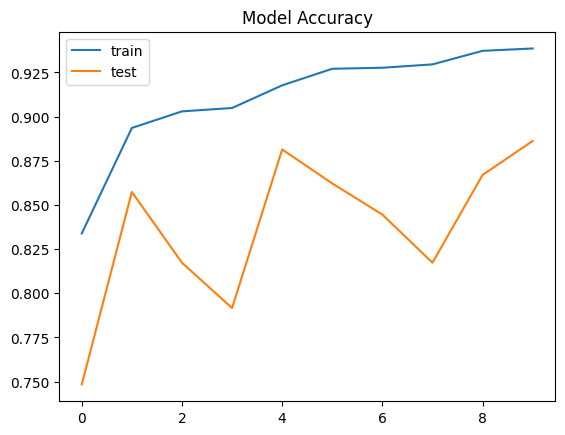

In [ ]:
# Learning curve
# Plot Accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.title('Model Accuracy')
plt.legend()
plt.show()

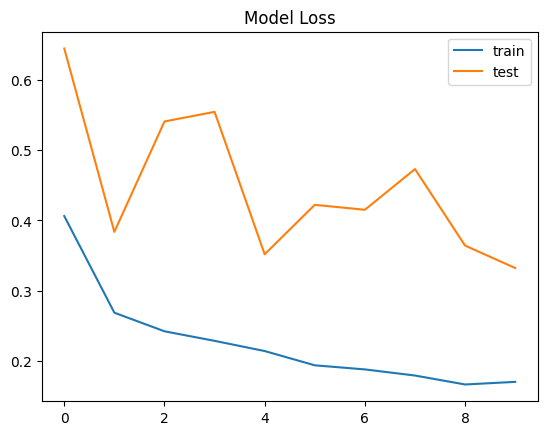

In [ ]:
# Plot Loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Model Loss')
plt.legend()
plt.show()

### Confusion Matrix

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# 1. Get predictions
predictions = model.predict(test_set)
# Since sigmoid gives a probability (0.0 to 1.0), we convert to 0 or 1
y_pred = (predictions > 0.5).astype(int)

# 2. Get true labels
y_true = test_set.classes

# 3. Create the matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# 4. Detailed Report (Precision, Recall, F1-Score)
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step
Confusion Matrix:
[[184  50]
 [ 21 369]]
              precision    recall  f1-score   support

      Normal       0.90      0.79      0.84       234
   Pneumonia       0.88      0.95      0.91       390

    accuracy                           0.89       624
   macro avg       0.89      0.87      0.88       624
weighted avg       0.89      0.89      0.88       624



### Test on a Single "Mystery" Image

In [ ]:
from tensorflow.keras.preprocessing import image

In [ ]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img) / 255.0  # Remember to rescale!
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

    result = model.predict(img_array)
    if result[0][0] > 0.5:
        print(f"Prediction: Pneumonia ({result[0][0]*100:.2f}%)")
    else:
        print(f"Prediction: Normal ({(1-result[0][0])*100:.2f}%)")